<a href="https://colab.research.google.com/github/zzzer0-wav/myDTA_2026/blob/main/homework/practice_stat_tests_HARDER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Статистичні тести: поглиблений практикум

**Рівень:** середній+ · фокус на **інтерпретації** · бібліотека `scipy.stats`

---

Цей практикум складніший за попередній. Тут менше «механічного» застосування тестів і більше **роздумів**: ви будете обирати тести самостійно, помічати пастки і — найголовніше — **пояснювати, що результат означає для бізнесу**.

### Що нового порівняно з минулим практикумом
- 🧠 Більшість завдань вимагають, щоб ви **самі обрали тест** і обґрунтували вибір.
- 🪤 Тут є **пастки**: випадки, де p < 0.05, але результат практично не важливий; де дані спотворені викидами; де результат «на межі».
- 💬 На кожне завдання — **розгорнута інтерпретація**. Саме це відрізняє аналітика від калькулятора.

### Як працювати
1. До кожного завдання є **підказки** — користуйтесь ними, але спершу подумайте самі.
2. Інтерпретації пишіть так, ніби пояснюєте керівнику **без** статистичної освіти.
3. Не зупиняйтесь на «p < 0.05, значущо» — завжди питайте: *наскільки великий ефект? чи це важливо на практиці? чи можна довіряти даним?*

> ⚠️ Головна теза практикуму: **статистична значущість ≠ практична важливість.** Тримайте це в голові протягом усієї роботи.

---

## Підготовка

Працюємо з даними SaaS-продукту (онлайн-сервіс за підпискою). Запустіть клітинку нижче.

**`saas_users.csv`** — 1200 користувачів:

| Стовпець | Опис | Тип |
|---|---|---|
| `user_id` | ID користувача | — |
| `plan` | Тариф (Free / Pro / Business) | категоріальний |
| `region` | Регіон (Europe / Americas / Asia) | категоріальний |
| `signup_source` | Джерело реєстрації (Search / Referral / Ads / Social) | категоріальний |
| `support_tickets` | Кількість звернень у підтримку | числовий |
| `weekly_sessions` | Сеансів на тиждень | числовий |
| `feature_adopted` | Чи почав користуватись новою функцією (Так/Ні) | категоріальний |
| `nps_before` | Оцінка лояльності NPS ДО оновлення (0-10) | числовий |
| `nps_after` | NPS ПІСЛЯ оновлення (0-10) | числовий |

**`onboarding_ab.csv`** — A/B-тест нового онбордингу (100 000 користувачів!):

| Стовпець | Опис |
|---|---|
| `user_id` | ID |
| `variant` | Control (старий онбординг) або Treatment (новий) |
| `signed_up` | Чи завершив реєстрацію (1/0) |


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

users = pd.read_csv("saas_users.csv")
ab = pd.read_csv("onboarding_ab.csv")

print("Користувачі:", users.shape)
print("A/B онбординг:", ab.shape)
users.head()

Користувачі: (1200, 9)
A/B онбординг: (100000, 3)


,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after
0,10001,Free,Americas,Social,2,11,Так,5,3
1,10002,Pro,Asia,Search,12,16,Ні,6,3
2,10003,Free,Asia,Social,6,11,Ні,5,5
3,10004,Business,Americas,Referral,4,27,Ні,7,7
4,10005,Pro,Asia,Referral,1,8,Ні,4,6


---
# Розділ 1. Спочатку — подивись на дані уважно

## 🟦 Чому це важливо
Перш ніж застосовувати тести, аналітик завжди вивчає дані. Тести роблять припущення (наприклад, t-тест найкраще працює, коли дані приблизно симетричні). Якщо дані сильно спотворені викидами — середнє може вводити в оману, і висновок тесту теж.

#### ✏️ Завдання 1 (код)

Виведіть описову статистику (`.describe()`) для числових стовпців. Окремо порівняйте **середнє** і **медіану** стовпця `support_tickets`.

> 💡 **Підказка:** Для медіани: `users['support_tickets'].median()`. Зверніть увагу, чи сильно середнє відрізняється від медіани.

In [2]:
# Завдання 1:
display(users.describe())
display(users.support_tickets.median())

,user_id,support_tickets,weekly_sessions,nps_before,nps_after
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,10600.500000,2.105000,11.500833,6.930000,7.149167
std,346.554469,2.606333,6.395109,1.916114,2.200216
min,10001.000000,0.000000,1.000000,1.000000,0.000000
25%,10300.750000,0.000000,7.000000,6.000000,6.000000
50%,10600.500000,1.000000,11.000000,7.000000,7.000000
75%,10900.250000,3.000000,16.000000,8.000000,9.000000
max,11200.000000,20.000000,38.000000,10.000000,10.000000


1.0

#### 💬 Інтерпретація 1

Порівняйте середнє і медіану `support_tickets`. Що це говорить про форму розподілу (чи є викиди — користувачі з дуже великою кількістю звернень)? Чому для такого стовпця варто бути обережним із t-тестом?

> 🧭 **Орієнтир для відповіді:** Якщо середнє помітно більше за медіану — розподіл «витягнутий» вправо (є кілька користувачів з дуже багатьма зверненнями). Подумайте, як викиди впливають на середнє.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

У середньому 2 звернення для кожного користувача, але медіана - 1.0. Це свідчить про те, що є користувачі з великою кількостю звернень, саме це й здвинуло середнє до 2х звернень, але це не є правдивим середнім, медіана тут більш точно каже про середню кількість звернень на людину. Для стовпця support_tickets варто обмежитись t-testom, тому що у нас є одна числова категорія яку нам треба перевірити.

#### ✏️ Завдання 2 (код)

Побудуйте гістограму `support_tickets`, щоб побачити розподіл на власні очі.

> 💡 **Підказка:** `users['support_tickets'].plot(kind='hist', bins=20)` і потім `plt.show()`.

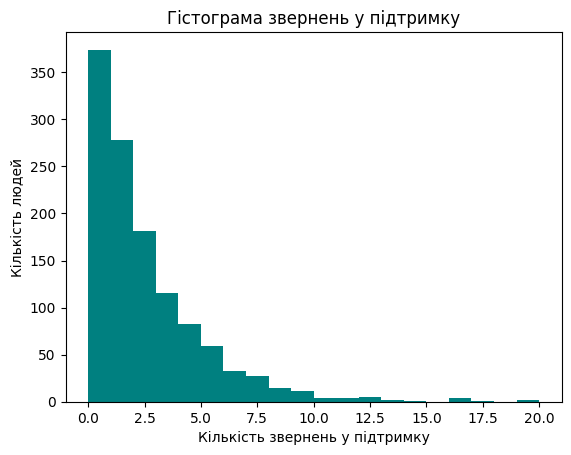

In [3]:
# Завдання 2:
users.support_tickets.plot(kind='hist', bins=20, color='teal')
plt.title('Гістограма звернень у підтримку')
plt.xlabel('Кількість звернень у підтримку')
plt.ylabel('Кількість людей');

#### 💬 Інтерпретація 2

Що видно на гістограмі? Підтверджує вона ваш висновок про викиди з попереднього завдання?

> 🧭 **Орієнтир для відповіді:** Опишіть форму: чи більшість значень малі, а «хвіст» тягнеться до великих? Це типовий скошений (skewed) розподіл.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

На гістограмі видно, що більшість клієнтів не зверталися до підтримки взагалі та в основному ті хто зверталися, насчитують до 10 звернень на людину, далі хвіст гістограми показує невелику кількість викидів. Невелика кількість клієнтів звертаються від 10 до 12.5, а дехто навіть 16 та 20 разів. Саме ці показники збивають середнє вгору.

---
# Розділ 2. Порівняння кількох груп — обери тест сам

## 🟦 Нагадування
Коли треба порівняти числову величину між **3+ групами**, згадайте, який тест підходить. Не забувайте: він каже лише, що різниця *десь є*, але не каже, *між якими саме* групами.

#### ✏️ Завдання 3 (код)

Користувачі різних тарифів (`plan`) можуть по-різному користуватись продуктом. Перевірте, чи відрізняється середня кількість сеансів на тиждень (`weekly_sessions`) між тарифами Free / Pro / Business. Спершу виведіть середні по групах, потім проведіть відповідний тест.

> 💡 **Підказка:** Три групи + числова змінна → ANOVA (`stats.f_oneway`). Зберіть групи у список: `[users[users.plan==p].weekly_sessions for p in users.plan.unique()]`.

In [4]:
# Завдання 3:
for p in users.plan.unique():
    subset = users[users.plan==p]
    print(f'{p}: {round(subset.weekly_sessions.mean(), 5)}')

groups = [users[users['plan']==ch]['weekly_sessions'] for ch in users['plan'].unique()]
[[], [], []]

f_stat, p_value = stats.f_oneway(*groups)

print(f'\np-value: {p_value}')
if p_value < 0.05:
    print('\nОдин канал точно значущо відрізняяється від інші')
else:
    print('\nЦе випадковість, середнє не вірне')

Free: 7.93167
Pro: 13.2993
Business: 19.5858

p-value: 1.090773844553071e-137

Один канал точно значущо відрізняяється від інші


#### 💬 Інтерпретація 3

Чи відрізняються тарифи за активністю? Який тариф найактивніший? І ключове питання: чому за результатом ANOVA ви НЕ можете одразу стверджувати, що, наприклад, Pro значущо активніший за Free? Що для цього треба було б зробити додатково?

> 🧭 **Орієнтир для відповіді:** ANOVA виявляє різницю «хоча б десь». Для конкретних пар потрібні post-hoc тести (напр. Тьюкі) або попарні порівняння з поправкою на множинність.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 4 (код)

Тепер перевірте, чи відрізняється `weekly_sessions` між регіонами (`region`).

> 💡 **Підказка:** Той самий тест, що й вище, але групуєте за `region`.

In [21]:
# Завдання 4:
for r in users.region.unique():
    subset = users[users.region==r]
    print(f'{r}: {round(subset.weekly_sessions.mean(),2)}')

groups = [users[users['region']==r]['weekly_sessions'] for r in users.region.unique()]
f_stat, p_value = stats.f_oneway(*groups)
if p_value < 0.05:
    print(f'p_value = {p_value}, oдин з регіонів значно відзірняється від інших')
else:
    print(f'p_value = {p_value}, pізниця випадкова!')
# print(f'p_value = {p_value}')

Americas: 10.78
Asia: 11.52
Europe: 12.28
p_value = 0.0040059700759991265, oдин з регіонів значно відзірняється від інших


#### 💬 Інтерпретація 4

Порівняйте цей результат із попереднім (тарифи). В одному випадку різниця значуща, в іншому — ні (або слабша). Що це означає для продукту: який фактор (тариф чи регіон) сильніше пов'язаний з активністю користувача?

> 🧭 **Орієнтир для відповіді:** Зверніть увагу не лише на сам факт значущості, а й на те, наскільки далекі середні між групами одне від одного.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Тарифи значно сильніше пов'язані з активністю користувачів, ніж регіон.
Різниця середніх між тарифами велика (Free +/-7.9 проти Business +/-19.6 сесій),
тоді як між регіонами вона незначна (Americas +/-10.8 проти Europe +/-12.3).
Це підтверджується і p-value: 1e-137 для тарифів проти 0.004 для регіонів.

---
# Розділ 3. До і після — і розмір ефекту

## 🟦 Новий акцент: розмір ефекту
Тут ви зустрінете важливу пастку. Тест може показати «значущо» (p < 0.05), але **величина зміни** може бути крихітною. Аналітик завжди дивиться на обидві речі: і p-значення, і **наскільки великий** ефект.

#### ✏️ Завдання 5 (код)

Компанія оновила онбординг і виміряла NPS (лояльність) тих самих користувачів до (`nps_before`) і після (`nps_after`). Проведіть відповідний тест. Додатково порахуйте **середню зміну** NPS (різницю after − before).

> 💡 **Підказка:** Ті самі користувачі двічі → парний t-тест (`stats.ttest_rel`). Середня зміна: `(users['nps_after'] - users['nps_before']).mean()`.

In [28]:
# Завдання 5:
print(f'Mean nps_before: {round(users.nps_before.mean(), 2)}')
print(f'Mean nps_after: {round(users.nps_after.mean(), 2)}')

t, p = stats.ttest_rel(users.nps_before, users.nps_after)

if p < 0.05:
    print(f'p-value = {p}, різниця статистично значуща (не випадкова)')
else:
    print(f'p-value = {p}, різниця статистично НЕ значуща (випадкова)')

Mean nps_before: 6.93
Mean nps_after: 7.15
p-value = 4.659740480089134e-08, різниця статистично значуща (не випадкова)


#### 💬 Інтерпретація 5

Тут — важлива пастка. Подивіться на p-значення І на розмір зміни. Чи зміна статистично значуща? А наскільки вона велика в балах NPS? Чи варто компанії святкувати «значуще покращення», якщо середній NPS зріс лише на ~0.2 бала з 10? Сформулюйте збалансований висновок.

> 🧭 **Орієнтир для відповіді:** Розрізняйте «статистично значущо» (різниця не випадкова) і «практично важливо» (різниця достатньо велика, щоб мати сенс для бізнесу). Тут перше — так, а друге — під питанням.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

p-value показує, що лояльність змінилася не випадково (статистично значущо),
але дуже невелика різниця між середніми (0.2 бала) свідчить про те,
що зміна практично незначуща — вона надто мала, щоб мати реальну цінність для бізнесу.

---
# Розділ 4. 🪤 Велика пастка: A/B-тест на 100 000 користувачів

## 🟦 Контекст
Це найважливіший розділ практикуму. Компанія протестувала новий онбординг (Treatment) проти старого (Control) на **100 тисячах** користувачів. Через величезний обсяг даних тут виявляється класична пастка статистики.

#### ✏️ Завдання 6 (код)

Порахуйте конверсію реєстрації (`signed_up`) для кожного варіанта (Control і Treatment). На скільки **відсоткових пунктів** відрізняється конверсія?

> 💡 **Підказка:** `ab.groupby('variant')['signed_up'].mean()`. Відсоткові пункти = різниця часток × 100.

In [52]:
# Завдання 6:
conv = ab.groupby('variant')['signed_up'].mean()
dif_conv = conv['Treatment'] - conv['Control']
dif_conv = dif_conv * 100

print(f"Control:   {conv['Control']:.2%}")     # :.2% сам умножит на 100 и добавит %
print(f"Treatment: {conv['Treatment']:.2%}")
print(f'Різниця: {round(dif_conv, 2)}%')

Control:   19.88%
Treatment: 20.76%
Різниця: 0.89%


#### 💬 Інтерпретація 6

Яка різниця конверсій між варіантами у відсоткових пунктах? На перший погляд — це багато чи мало?

> 🧭 **Орієнтир для відповіді:** Просто опишіть числа поки що. Наприклад, «різниця склала менше 1 відсоткового пункту».

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Конверсія сontrol - 19.88%, Treatment - 20.76%, різниця 0.89% може здаватися незначущою, але майже 1% для регестрації може бути відчутним, варто перевірити статистично.

#### ✏️ Завдання 7 (код)

Проведіть статистичний тест, щоб перевірити, чи різниця конверсій значуща (дані категоріальні: варіант × signed_up).

> 💡 **Підказка:** Категоріальні дані → хі-квадрат. `pd.crosstab(ab.variant, ab.signed_up)`, потім `stats.chi2_contingency`.

In [59]:
# Завдання 7:
cont = pd.crosstab(ab.variant, ab.signed_up)

chi2, p, dof, expacted = stats.chi2_contingency(cont)

if p < 0.05:
    print(f'Різниця статистично значуща, p = {p:2e}')
else:
    print(f'Різниця статистично незначуща, p = {p:2e}')

Різниця статистично значуща, p = 4.986017e-04


#### 💬 Інтерпретація 7

🪤 ОСЬ ПАСТКА. Тест майже напевно покаже, що різниця **статистично значуща** (p < 0.05). Але різниця в конверсії — менше 1 відсоткового пункту. Поясніть цей парадокс: як крихітна різниця може бути «значущою»? Яку роль тут відіграє величезний обсяг вибірки (100 тисяч)?

> 🧭 **Орієнтир для відповіді:** При дуже великих вибірках навіть мікроскопічні різниці стають статистично значущими, бо тест дуже «чутливий». Значущість говорить «різниця не нульова», але нічого не каже про те, чи вона ВЕЛИКА.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Різниця статистично значуща (р = 0.00005), бо вибірка дуже велика (100 000 користувачів), на такому обсязі даних тест стає дуже чутливим і різниця майже в один відсоток для нього не випадкова. Але р показує лише, що різниця реальна, а не що вона велика. Розмір ефекту залишається малим незалежно від р.

#### 💬 Інтерпретація 8

Фінальне рішення аналітика. Уявіть, що впровадження нового онбордингу коштує дорого (треба переписати код, навчити команду). Чи варто впроваджувати Treatment заради приросту в ~0.9 відсоткового пункту? Сформулюйте аргументовану рекомендацію, яка враховує і статистику, і практичний бік.

> 🧭 **Орієнтир для відповіді:** Тут немає єдиної правильної відповіді — важлива логіка. Згадайте: статистична значущість ≠ практична важливість. Варто зважити розмір ефекту проти вартості впровадження та обсягу бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Результат тестів свідчить про те, що різниця статистично значуща, але мала (0.89). Чи впроваджувати новий онбординг - залежить від масштабу бізнесу. 0.89% це 890 додаткових реєестрація на 100к користувачів, якщо в компанії мільйон користувачів - це десятки тисяч реєстрацій. У такому разі він може себе окупити та залучити нових користувачів. Якщо база невелика - приріст не вартий витрат.
Також треба порівняти скільки приносить один зареєстрований користувач * кількість додаткових реєстрацій із вартістю переписування коду та навчання команди.

Спочатку порахувати очікуваних дохід на реальному обсязу бізнесу і зіставити з витратами, якщо дохід перевищує - впропаджувати.

---
# Розділ 5. Зв'язок категорій — і результат «на межі»

## 🟦 Що тренуємо
Тут — звичайний хі-квадрат, але один із результатів буде **близьким до межі 0.05**. Це привід поговорити про те, що поріг 0.05 — умовність, а не магія.

#### ✏️ Завдання 8 (код)

Перевірте, чи пов'язаний тариф (`plan`) із тим, чи почав користувач застосовувати нову функцію (`feature_adopted`). Побудуйте таблицю спряженості і проведіть тест.

> 💡 **Підказка:** Дві категоріальні змінні → хі-квадрат. Не забудьте спершу `pd.crosstab(users.plan, users.feature_adopted)`.

In [93]:
cross_counts = pd.crosstab(users.plan, users.feature_adopted)
cross_norm = pd.crosstab(users.plan, users.feature_adopted, normalize='index')
print(f'{cross_norm}')

chi2, p, dof, expected = stats.chi2_contingency(cross_counts)
if p < 0.05:
    print(f'\nРізниця статистично значуща, p = {p}')
else:
    print(f'\nРізниця статистично не значуща, p = {p}')

feature_adopted        Ні       Так
plan                               
Business         0.319527  0.680473
Free             0.755000  0.245000
Pro              0.473318  0.526682

Різниця статистично значуща, p = 8.29605002229765e-32


#### 💬 Інтерпретація 9

Чи пов'язаний тариф із прийняттям функції? Подивіться на таблицю спряженості: користувачі якого тарифу найчастіше приймають функцію? Що це означає для продуктової стратегії?

> 🧭 **Орієнтир для відповіді:** Порахуйте частку «Так» у кожному тарифі (наприклад, для Business: Так / (Так+Ні)). Порівняйте частки між тарифами.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Зв'язок між тарифом і прийняттям функції статистично значущий (p < 0.05).

Найбільша частка "Ні" у free плана, найменша у бізнес тарифі.
Та найбільша частка "Так" перепадає також на бізнес тариф.
Судячи з часток "Так" і "Ні" для кожного з тарифів, можна припустити, що користувачі, які платять кошти - більш заохочені у нових "фічах" ніж користувачі з free планом.

Рекомендую розвивати фічі для платних тарифів і окремо з'ясувати що саме зупиняє free користувачів.

#### ✏️ Завдання 9 (код)

Тепер перевірте, чи пов'язане джерело реєстрації (`signup_source`) із прийняттям функції (`feature_adopted`).

> 💡 **Підказка:** Знову хі-квадрат, але для `signup_source` × `feature_adopted`.

In [76]:
# Завдання 9:
cross2 = pd.crosstab(users.signup_source, users.feature_adopted)
cross2_norm = pd.crosstab(users.signup_source, users.feature_adopted, normalize='index')
print(cross2_norm)

chi2, p, dof, expected = stats.chi2_contingency(cross2)
if p < 0.05:
    print(f'\nРізниця статистично значуща, p = {p}')
else:
    print(f'\nРізниця не значуща, р = {p}')

feature_adopted        Ні       Так
signup_source                      
Ads              0.619048  0.380952
Referral         0.638989  0.361011
Search           0.549637  0.450363
Social           0.568966  0.431034

Різниця не значуща, р = 0.071828863875168


#### 💬 Інтерпретація 10

Цей результат, імовірно, буде «на межі» (p близько 0.05–0.07). Як трактувати такий пограничний випадок? Чи коректно сказати «майже значущо» і впевнено заявити про зв'язок? Що б ви порадили зробити, перш ніж робити висновок?

> 🧭 **Орієнтир для відповіді:** Поріг 0.05 — умовність. Результат трохи вище 0.05 означає «недостатньо доказів за обраного порогу». Не варто оголошувати зв'язок; розумно зібрати більше даних або поставитись обережно.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Результат тесту показує р-значення яке близько до межі (р=0.07), це значить, що доказів проти нульової гіпотези все одно недостатньо, треба перевірити результат на іншій, або більшій вибірці.

Проте в частках видно тенденцію: користувачі з search (45%) і social (43%)
приймають функцію частіше, ніж з ads (38%) і referral (36%).
Можливо, зв'язок існує, але поточної вибірки замало, щоб його підтвердити.

---
# Розділ 6. Кореляція та хибні висновки про причинність

## 🟦 Що тренуємо
Числові зв'язки + критичне мислення про причинність.

#### ✏️ Завдання 10 (код)

Перевірте, чи пов'язана кількість звернень у підтримку (`support_tickets`) із кількістю сеансів на тиждень (`weekly_sessions`). Порахуйте кореляцію Пірсона.

> 💡 **Підказка:** `stats.pearsonr(users['support_tickets'], users['weekly_sessions'])`. Дивіться і на r, і на p.

In [78]:
# Завдання 10:
t, p = stats.pearsonr(users['support_tickets'], users['weekly_sessions'])

if p < 0.05:
    print(f'Різниця значуща, р = {p}')
else:
    print(f'Різниця не значуща, р = {p}')

Різниця не значуща, р = 0.31604933607929614


#### 💬 Інтерпретація 11

Опишіть зв'язок (сила, напрямок, значущість). Уявіть, що колега каже: «Більше звернень у підтримку — значить, треба зменшити кількість сеансів, бо сеанси викликають проблеми». Що не так із цим міркуванням?

> 🧭 **Орієнтир для відповіді:** По-перше, оцініть, чи зв'язок узагалі є (подивіться на r і p). По-друге — навіть за наявності зв'язку кореляція не доводить причинність; напрямок «сеанси → звернення» — лише припущення.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Спостерігається прямий але не сильний зв'язок (p = 0.31). Міркування невірне, тому що насправді чим частіше користувачі користуються, тим частіше вони стикаються з проблемами і звертаються до підтримки. Варто змернути увагу на що скаржаться користувачі і пофіксити це у першу чергу.

---
# Розділ 7. 🧩 Відкритий кейс: повний аналіз

## 🟦 Завдання-кейс
Тут немає підказок про конкретний тест — ви аналітик, і вам треба самостійно пройти весь шлях. Це імітація реального робочого завдання.

**Ситуація:** керівництво хоче зрозуміти, що відрізняє користувачів тарифу **Business** (найдорожчий) від інших. Ваша мета — знайти хоча б два статистично обґрунтовані інсайти про користувачів Business.

#### ✏️ Завдання 11 (код)

Крок 1. Створіть новий стовпець `is_business`, який дорівнює 'Так', якщо тариф Business, інакше 'Ні'. Це поділить користувачів на дві групи для порівнянь.

> 💡 **Підказка:** `users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})` або через `np.where`.

In [79]:
# Завдання 11:
# users['is_business'] = (users['plan'] == 'Business').map({True:'Tak', False:'Hi'})
users['is_business'] = np.where(users['plan'] == 'Business', 'Так', 'Ні')
users

,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after,is_business
0,10001,Free,Americas,Social,2,11,Так,5,3,Ні
1,10002,Pro,Asia,Search,12,16,Ні,6,3,Ні
2,10003,Free,Asia,Social,6,11,Ні,5,5,Ні
3,10004,Business,Americas,Referral,4,27,Ні,7,7,Так
4,10005,Pro,Asia,Referral,1,8,Ні,4,6,Ні
...,...,...,...,...,...,...,...,...,...,...
1195,11196,Free,Asia,Search,3,14,Ні,6,6,Ні
1196,11197,Pro,Asia,Search,0,20,Так,6,7,Ні
1197,11198,Free,Asia,Ads,0,11,Ні,5,1,Ні
1198,11199,Pro,Americas,Ads,1,12,Ні,3,5,Ні


#### ✏️ Завдання 12 (код)

Крок 2. Сформулюйте і перевірте ПЕРШУ гіпотезу: чи відрізняються Business-користувачі за `weekly_sessions` від решти? Оберіть і проведіть доречний тест.

> 💡 **Підказка:** Дві групи (Business vs решта) + числова змінна → двовибірковий t-тест (`stats.ttest_ind`).

In [86]:
# Завдання 12:
business = users[users['plan']=='Business']['weekly_sessions']
others = users[users['plan']!='Business']['weekly_sessions']
print(f'business: {round(business.mean(), 2)}, others: {round(others.mean(), 2)}')

t, p = stats.ttest_ind(business, others)

if p < 0.05:
    print(f'Різниця значуща, р = {p}')
else:
    print(f'Різниця не значуща, р = {p}')

business: 19.59, others: 10.18
Різниця значуща, р = 3.497217655926265e-81


#### 💬 Інтерпретація 12

Сформулюйте перший інсайт: чим Business-користувачі відрізняються за активністю? Наведіть і числа (середні), і висновок тесту.

> 🧭 **Орієнтир для відповіді:** Порівняйте середні двох груп і вкажіть, чи різниця значуща. Перекладіть це мовою бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Так, судячи з різниці середнього та результату тесту - можна сказати, що business користувачі мають майже у 2 рази більше сессій за тиждень ніж користувачі з іншими планами (19.59 business / 10.18 others). Та на значущу різницю вказує p-value = 0.000...00349.

#### ✏️ Завдання 13 (код)

Крок 3. Сформулюйте і перевірте ДРУГУ гіпотезу: чи пов'язаний статус Business із прийняттям функції (`feature_adopted`)? Оберіть доречний тест.

> 💡 **Підказка:** Дві категоріальні змінні (`is_business` × `feature_adopted`) → хі-квадрат.

In [90]:
# Завдання 13:
cross3 = pd.crosstab(users.is_business, users.feature_adopted)
cross3_norm = pd.crosstab(users.is_business, users.feature_adopted, normalize='index')
print(cross3_norm)

chi2, p, dof, expected = stats.chi2_contingency(cross3)

if p < 0.05:
    print(f'\nРізниця значуща, р = {p}')
else:
    print(f'\nРізниця не значуща, р = {p}')

feature_adopted        Ні       Так
is_business                        
Ні               0.637245  0.362755
Так              0.319527  0.680473

Різниця значуща, р = 1.2883025485412675e-14


#### 💬 Інтерпретація 13

Сформулюйте другий інсайт. Чи частіше Business-користувачі приймають нову функцію?

> 🧭 **Орієнтир для відповіді:** Подивіться на частки «Так» у групах Business та не-Business у таблиці спряженості.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Так, business користувачі у 68% випадках налаштовують фічі, та лише у 31% випадках відмовлюються. Усі інші навпаки погоджуються лише у 36% випадках, та відмовлюються у 63% випадках.

Це свідчить про те, що треба дізнатися причину відмовлень що до фічі, та поновлювати іх для Business користувачів, які їми користуються.

#### 💬 Інтерпретація 14

Підсумок кейсу. Зберіть ваші знахідки в короткий звіт (3-4 речення) для керівництва: який «портрет» Business-користувача вимальовується з даних? Які з висновків статистично надійні, а де варто бути обережним?

> 🧭 **Орієнтир для відповіді:** Хороший звіт поєднує кілька знахідок, чесно зазначає рівень упевненості й уникає тверджень про причинність там, де є лише кореляція.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Business користувачі (які платять нам гроші за підписку)  - найцінніший сегмент. Вони набагато лояльніше та з інтересом відносяться до нововведеть у застосунку (сайті). Також вони мають майже у 2 рази більше сессій на тиждень порівняно з іншими користувачами.

Обидва висновки статистично надійні (дуже малі p, різниця не випадкова). Проте варто бути обережним з причинністю, дані показують зв'язок, але не доводять, що саме тариф впливає на активність, можливо активні користувачі самі обирають дорожчий план.

---
# 🎉 Готово!

Ви пройшли поглиблений практикум, де головним було не «порахувати p-значення», а **зрозуміти й пояснити** результат.

## Що ви потренували
- ✅ Самостійний вибір тесту під задачу
- ✅ Розрізнення **статистичної значущості** та **практичної важливості** (пастка з 100 000 користувачів)
- ✅ Увагу до **розміру ефекту**, а не лише до p < 0.05
- ✅ Обережність із **скошеними даними** та викидами
- ✅ Трактування **пограничних** результатів (p ≈ 0.05)
- ✅ Критичне мислення про **причинність** (кореляція ≠ причина)
- ✅ Складання звіту для бізнесу

## Головна думка
> P-значення — це початок розмови, а не її кінець. Хороший аналітик завжди питає далі: *наскільки великий ефект? чи це важливо? чи можна довіряти даним? чи це причина — чи лише зв'язок?*

Якщо ви відчуваєте, що на ці питання вмієте відповідати — ви виросли від «людини, що рахує тести» до **аналітика, що ухвалює рішення**. 📊
